<a href="https://colab.research.google.com/github/aashikagarg/Machine-Learning/blob/main/Loan_Default_Dataset(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Loan_Default.csv to Loan_Default.csv


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Loan_Default.csv')

# View first few rows
df.head()

# Get dataset info
df.info()

# Summary statistics
df.describe(include='all')

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [3]:
# Handle missing values (example)
df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)

# Convert categorical variables
df['Status'] = df['Status'].astype('category')

# Drop unnecessary columns
df.drop(['ID', 'year'], axis=1, inplace=True)

<ipython-input-3-048c617d9bd6>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)


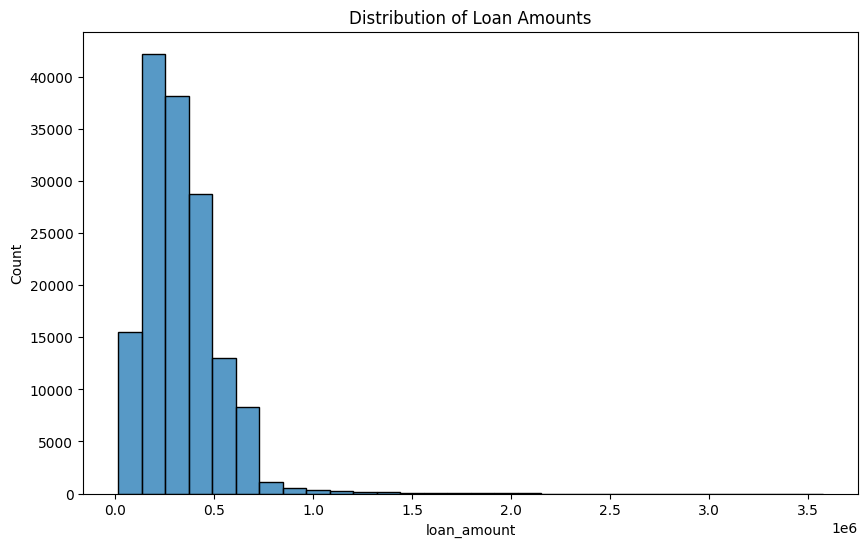

ValueError: could not convert string to float: 'cf'

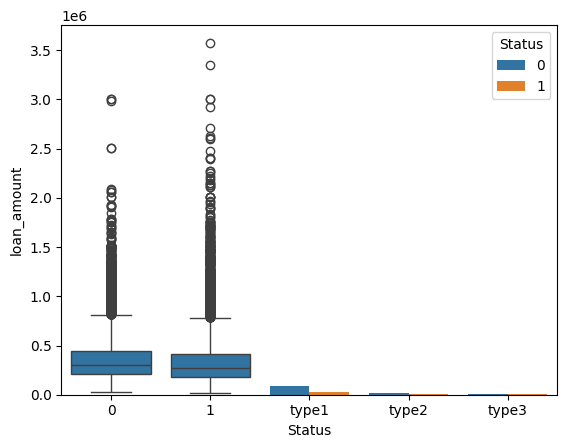

<Figure size 1200x800 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of loan amounts
plt.figure(figsize=(10,6))
sns.histplot(df['loan_amount'], bins=30)
plt.title('Distribution of Loan Amounts')
plt.show()

# Boxplot of loan amount by default status
sns.boxplot(x='Status', y='loan_amount', data=df)

# Countplot of loan types
sns.countplot(x='loan_type', hue='Status', data=df)

# Heatmap of correlations
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Split data
X = df.drop('Status', axis=1)
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.select_dtypes(include=['float64', 'int64']))
X_test_scaled = scaler.transform(X_test.select_dtypes(include=['float64', 'int64']))